[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/michalis0/Business-Intelligence-and-Analytics/blob/master/labs/04%20-%20Pandas%20and%20Data%20Cleaning/Exercises/exercise_01.ipynb)



# EDA and data visualization

## EXERCISE 1

In this exercise you're going to put in practice what you just learned and implement the same types of charts.<br>
Those charts will help you to answer questions.

For this, we're going to use the same data-set we used in the walkthroughs.<br>

***Beware ! You need to clean the data-set to be able to answer the questions ;)***

## 1. Imports, data set and cleaning

### 1.1 Imports

First, you have to import the libraries you will need.

In [10]:
# Don't forget to import seaborn and scatter_matrix
import pandas as pd
import seaborn as sns
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

# Set some Pandas options
sns.set(style="darkgrid")
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### 1.2 Load the data-set

Here is the url to retrieve the data set : https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/Telco-Customer-Churn.csv



In [11]:
# Import data set and call head function
telco=pd.read_csv('https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/Telco-Customer-Churn.csv')
telco.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### 1.3 Converting column types


In [12]:
# Take a look at the column types
telco.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [28]:
import pandas as pd
telco = pd.read_csv('https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/Telco-Customer-Churn.csv')
# Add a newline for better readability
print('\n')

In [29]:
import pandas as pd
telco = pd.read_csv('https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/Telco-Customer-Churn.csv')
# Convert Total Charges to numeric, use error = 'coerce'
telco['TotalCharges']=pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [30]:
import pandas as pd
telco = pd.read_csv('https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/Telco-Customer-Churn.csv')
# What columns can be converted to the categorical type?
# Convert 3 of them here
telco['InternetService'] = pd.Categorical(telco['InternetService'], categories=['DSL', 'Fiber optic', 'No internet service'], ordered=True)
telco['gender']=pd.Categorical(telco['gender'],categories=['Male','Female'],ordered=True)
telco['PaymentMethod']=pd.Categorical(telco['PaymentMethod'],categories=['Electronic check','Mailed Check','Bank transfer (automatic)','Credit card (automatic)'],ordered=True)
telco.dtypes

,0
customerID,object
gender,category
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,category
OnlineSecurity,object


### 1.4 Boolean values

Remember that boolean values are either True or False. Use the `value_counts()` function to see what values compose the `seniorCitizen` column.

In [16]:
telco['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5901
1,1142


If you did it right, you should see that the column is composed only of 0's and 1's. We can consider the 1's for `True` and the 0's for `False`.

You can use the `astype` function for this, just pass 'bool' as an argument instead of 'category'.

What other columns can be converted to this type? Convert at least 3 of them.

In [17]:
telco['SeniorCitizen'].astype('bool')
telco['Churn'].astype('bool')
telco['Partner'].astype('bool')
telco.dtypes

,0
customerID,object
gender,category
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,category
OnlineSecurity,object


### 1.5 Cleaning the NaN values

Now since the data set contains NaN values, you will need to clean first before the analysis.

In [18]:
# Count the null values
telco.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,1526
OnlineSecurity,0


In [19]:
# Drop the null values
telco.dropna()
telco.dtypes


,0
customerID,object
gender,category
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,category
OnlineSecurity,object


## 2. First analysis
**Question:**
What is the proportion of women in our Data?

In [20]:
telco.gender.value_counts(normalize=True)

,proportion
gender,
Male,0.504756
Female,0.495244


## 3. Histogram

Now, plot an histogram of the `TotalCharges` column, use 20 bins.


<Axes: >

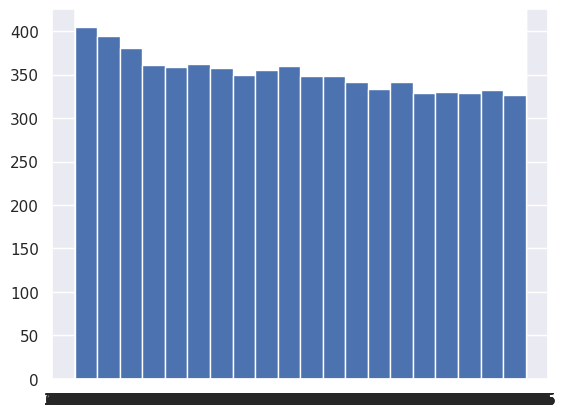

In [21]:
telco['TotalCharges'].hist(bins=20)

## 4. Boxplot

**Question:** What are the mean, median, min and the value of the third quartile of the `MonthlyCharges` and `TotalCharges` ?<br>

Plot both in one figure


<Axes: >

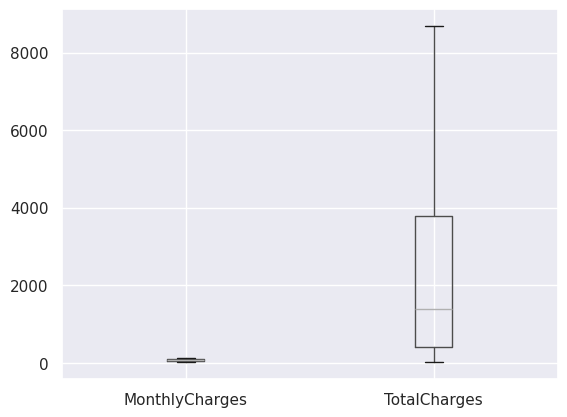

In [32]:
# Here for the visualization
telco.boxplot(column = ['MonthlyCharges','TotalCharges'])

In [33]:
import pandas as pd

# Re-load the data to ensure a fresh start for telco
telco = pd.read_csv('https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/Telco-Customer-Churn.csv')

# Convert TotalCharges to numeric, coercing errors to NaN
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')

# Fill any NaNs that resulted from the coercion with 0 or a more appropriate value if desired
# For plotting purposes, let's fill with 0 to keep the data complete, or drop if preferred.
# In this context, dropping them for TotalCharges is usually safer if they represent missing values.
telco.dropna(subset=['TotalCharges'], inplace=True)

print(telco.dtypes)
print(telco.head())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges  TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service            

Now that the `telco` DataFrame has been properly reloaded and the `TotalCharges` column is numeric, please re-run the boxplot cell (cell `251-kJdnrzxf`).

In [34]:
# Here for the numerical
telco['MonthlyCharges'].describe()


,MonthlyCharges
count,7032.000000
mean,64.798208
std,30.085974
min,18.250000
25%,35.587500
50%,70.350000
75%,89.862500
max,118.750000


In [35]:
telco['TotalCharges'].describe()

,TotalCharges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


## 5. Scatter Plot and lines


### 5.1 Scatter plot
**Question:** Is there a correlation between the `MonthlyCharges` and the `TotalCharges` ?

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

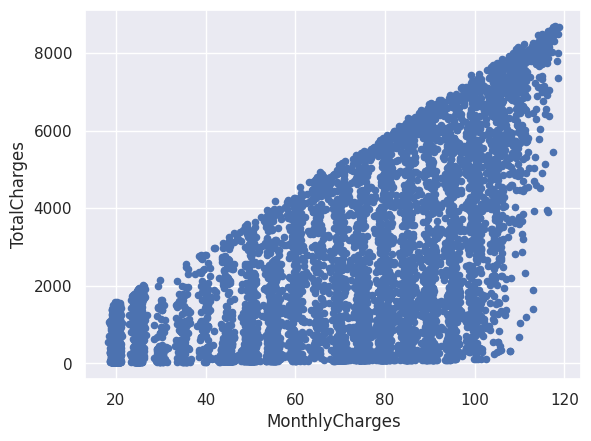

In [36]:
telco.plot.scatter(x='MonthlyCharges', y='TotalCharges')

### 5.2 Pair Grid
**Question:** Could you find any correlation between one of those values: `tenure`, `MonthlyCharges`, `TotalCharges` ?
 (Use scatterplot)

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

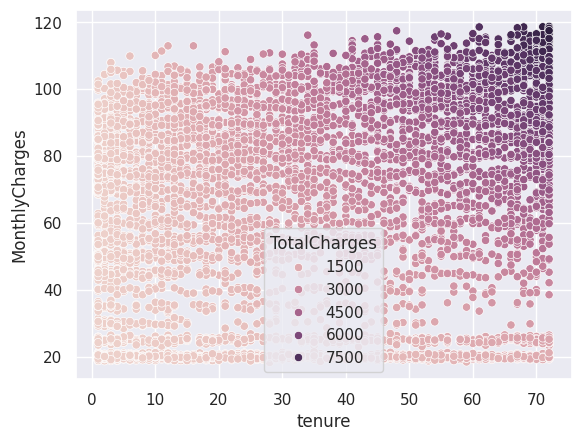

In [43]:
import seaborn as sns

sns.scatterplot(data=telco, x='tenure', y='MonthlyCharges', hue='TotalCharges')

## 6. Heatmap and correlations
Calculate the **correlation DataFrame**, and plot its **heatmap**. We have already processed and adapted the data for you, you just need to create a correlation matrix and plot the heatmap with `sns`.

<h2>Important: This heatmap helps answer the two-question quiz </h2>

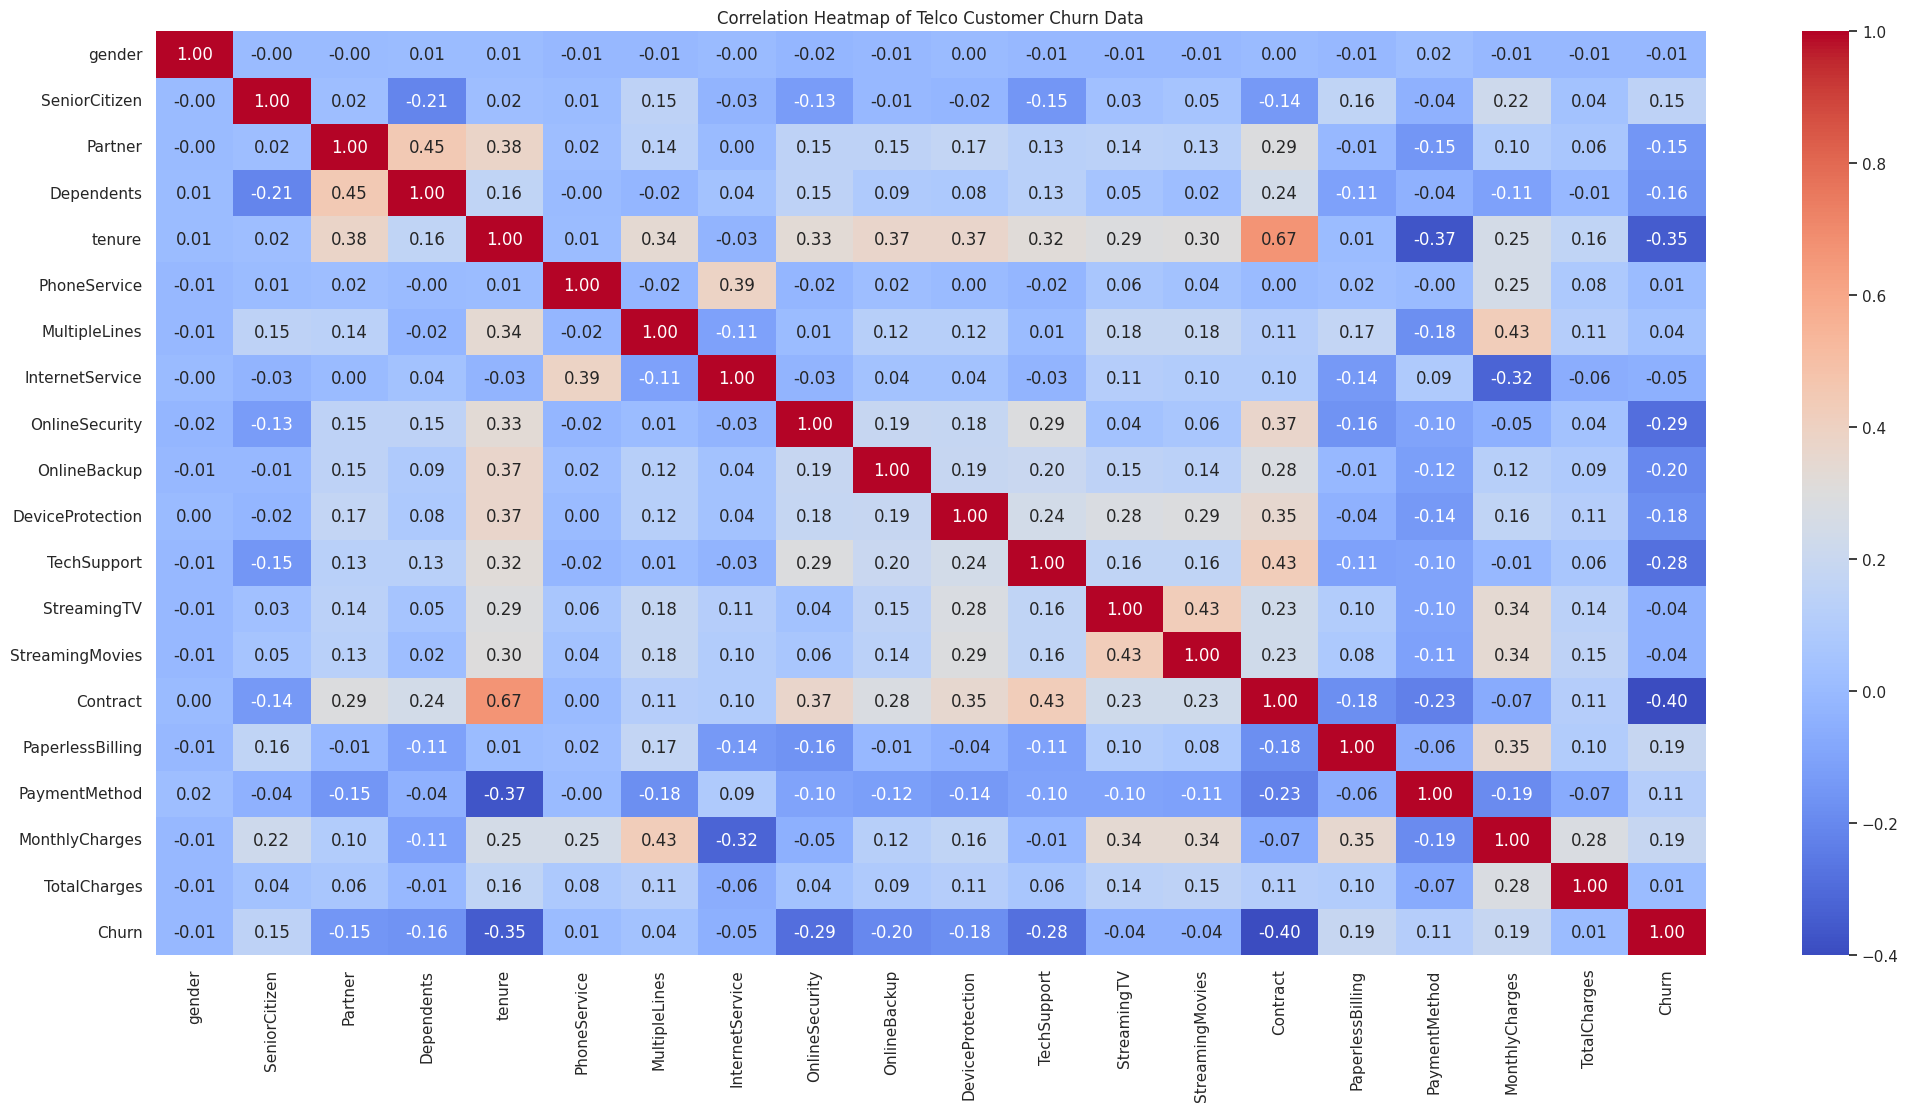

In [45]:
# ⚠️ Do not modify this code, as it is required for consistency in data processing
data_telco = pd.read_csv("https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/Telco-Customer-Churn.csv")
for col in data_telco.select_dtypes(include=['object']).columns:
    data_telco[col] = pd.Categorical(data_telco[col]).codes
data_telco.drop('customerID',axis=1,inplace=True)
plt.figure(figsize=(25, 12))


# Use the new DataFrame that we created just above and which is called "data_telco"
# Create the correlation DataFrame with "data_telco" and plot its heatmap
corr_matrix = data_telco.corr().round(2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Telco Customer Churn Data')
plt.show()

## 7. Plot the histogram with seaborn




Create two histograms to compare SeniorCitizen vs Churn and Gender vs Churn. You can use sns.countplot.

Tip: Use the "hue" parameter in sns.countplot() to differentiate the Churn categories within each SeniorCitizen and gender group.
If you have doubts, you can check the online documentation [here](https://seaborn.pydata.org/generated/seaborn.countplot.html?utm_source=chatgpt.com).

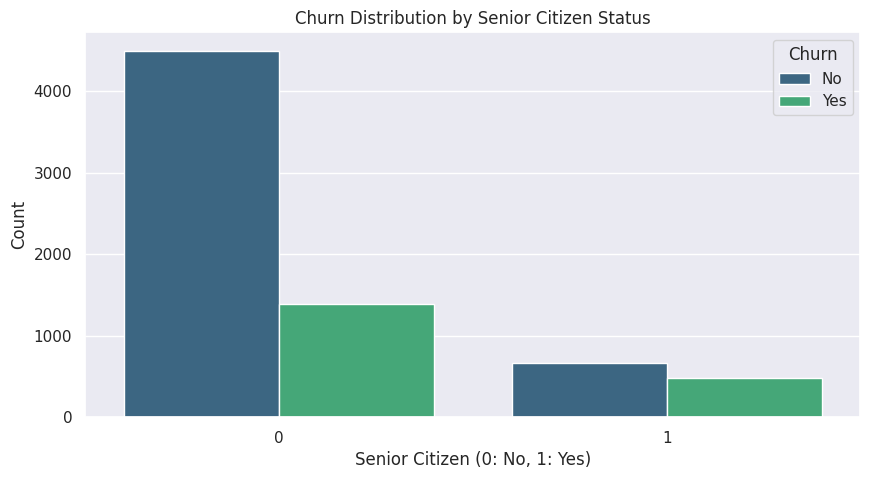

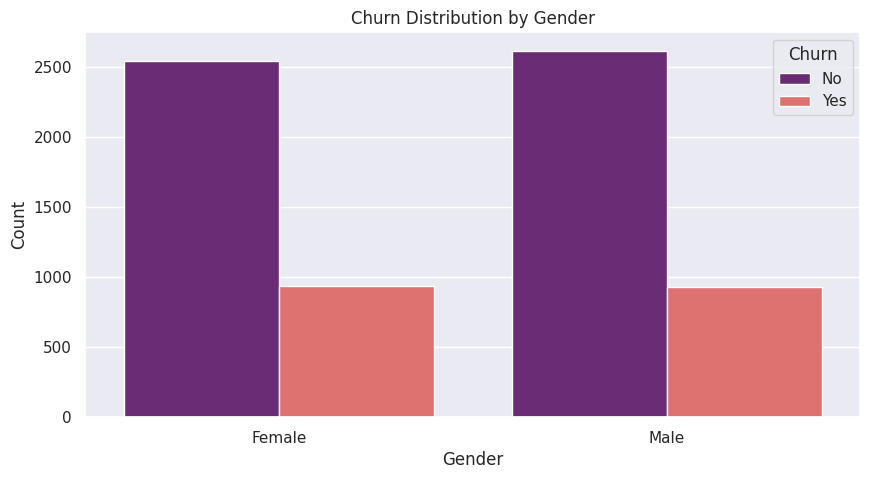

In [46]:
plt.figure(figsize=(10, 5))
sns.countplot(data=telco, x='SeniorCitizen', hue='Churn', palette='viridis')
plt.title('Churn Distribution by Senior Citizen Status')
plt.xlabel('Senior Citizen (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=telco, x='gender', hue='Churn', palette='magma')
plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()